# Autoregressive Conditional Heteroskedasticity (ARCH)
- periods of high volatility are followed by periods of even higher volatility
- periods of low volatility are followed by periods of even lower volatility

In practice this means that volatility tends to cluster.

## GARCH
- error varince is thought to be autocorrelated over time
- assume the variance of the error term follows a process based on an autoregressive moving average
- supposed to capture better long-term volatility patterns

## ARCH(q) == GARCH(0, q)

In [79]:
import numpy as np
from arch import arch_model
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath('..'))
from functions import line_plot

In [31]:
df = pd.read_csv('../Data/aluminium_pre_inputs.csv')

## Experiment 1:
GARCH(1, 1) model
- Next Day volatility calculation

In [70]:
context_window_length = 30
vols_pred = [0]*30
for i in range(30, df.shape[0]):
    model = arch_model(df['al_lme_prices_log_returns'][i:i+30], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
    res = model.fit(disp='off')
    volatility = res.conditional_volatility
    forecast = res.forecast(horizon=1)
    next_volatility = np.sqrt(forecast.variance.values[-1 ,0])
    vols_pred.append(next_volatility)

c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\volatility.py:1215: RuntimeWarning: invalid value encountered in scalar divide
  scale = np.mean(resids**2) / (target ** (2.0 / power))
c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertatio

In [72]:
model = arch_model(df['al_lme_prices_log_returns'], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
res = model.fit(disp='off')
vols_true = res.conditional_volatility

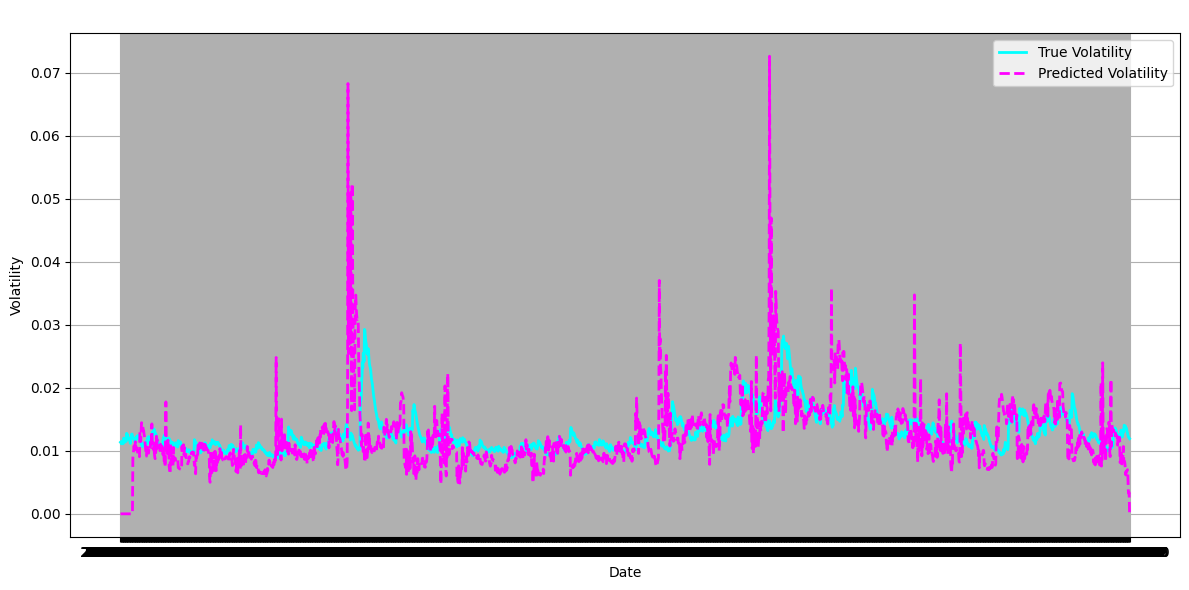

In [77]:
# Plot with dark background
plt.style.use('default')     
plt.figure(figsize=(12, 6))

# Plot lines
plt.plot(df['date'], vols_true, label='True Volatility', linewidth=2, color='cyan')
plt.plot(df['date'], vols_pred, label='Predicted Volatility', linewidth=2, linestyle='--', color='magenta')

# Labels and title in white
plt.title('True vs Predicted Volatility Over Time', color='white', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility')

# Customize ticks
plt.tick_params(axis='x')
plt.tick_params(axis='y')

# Grid
plt.grid(True)

# Legend
plt.legend()

# Layout
plt.tight_layout()
plt.show()

TypeError: line_plot() got an unexpected keyword argument 'linecolor'

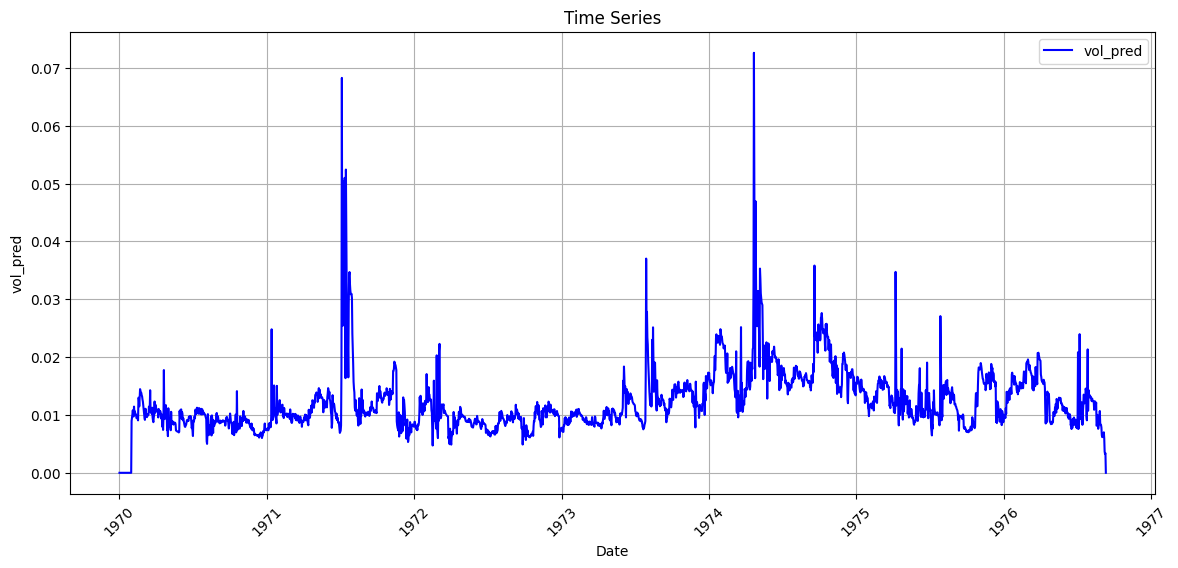

In [84]:
ax = line_plot(df['date'], vols_pred, 'vol_pred', show=False)
_ = line_plot(df['date'], vols_true, 'vol_true', linecolor='red', ax=ax, show=True)